# Machine Unlearning — Experimental Results

**Seed:** 42  
**Methods:** Naive Retrain (gold standard) · ∇τ (Grad-Tau) · SISA  
**Datasets:** CIFAR-10 · CIFAR-100  
**Forget strategy:** Random fraction of training set  

### Metric guide
| Metric | Ideal (post-unlearn) | Meaning |
|--------|---------------------|---------|
| `test_acc` | ≈ original baseline | General performance preserved |
| `retain_acc` | ≈ original baseline | Retained data still learned |
| `forget_acc` | ↓ (lower) | Forgotten samples less confidently classified |
| `MIA-L` | ≈ 50% | Loss-based membership inference indistinguishable |
| `MIA-E` | ≈ 50% | Entropy-based membership inference indistinguishable |
| `time (s)` | ↓ (faster) | Wall-clock unlearning time |

### ⚠️ SISA baseline note
SISA trains an **ensemble of 5 shards** — each shard uses only 1/5 of the data.  
Its "before unlearning" accuracy is therefore **lower than the single-model baseline**  
(≈80% vs 94% on CIFAR-10; ≈49% vs 76% on CIFAR-100).  
**The correct comparison for SISA is always against its own ensemble baseline,  
not against the single-model (Naive / ∇τ) baseline.**  
For timing, SISA unlearning time is compared against **SISA full re-train time** (not naive retrain).

In [1]:
import json
import glob
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 2,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

METHOD_LABELS = {
    'naive_retrain': 'Naive Retrain',
    'grad_tau':      '∇τ (Grad-Tau)',
    'sisa':          'SISA (ensemble)',
}
METHOD_COLORS = {
    'naive_retrain': '#2196F3',   # blue
    'grad_tau':      '#FF5722',   # deep orange
    'sisa':          '#4CAF50',   # green
}

# Two comparison groups:
#   single-model: naive_retrain, grad_tau share the same starting model
#   sisa:         sisa has its own ensemble starting point
SINGLE_MODEL_METHODS = ['naive_retrain', 'grad_tau']
CHECKPOINTS = Path('checkpoints')
print('Ready.')

Ready.


In [2]:
# ── Load data ────────────────────────────────────────────────────────────────

def load_results(results_json_path):
    """Load a seed_*_results.json list into a DataFrame."""
    with open(results_json_path) as f:
        runs = json.load(f)
    rows = []
    for r in runs:
        if r.get('status') != 'complete':
            continue
        row = {
            'dataset':          r['dataset'],
            'seed':             r['seed'],
            'method':           r['method'],
            'forget_fraction':  r['forget_fraction'],
            'forget_size':      r['forget_size'],
            'retain_size':      r['retain_size'],
            'unlearn_time_s':   r.get('unlearn_time_s'),
            'sisa_train_time_s': r.get('sisa_train_time_s'),   # only SISA rows
            # before
            'b_test_acc':   r['before']['test_acc'],
            'b_retain_acc': r['before']['retain_acc'],
            'b_forget_acc': r['before']['forget_acc'],
            'b_mia_l':      r['before']['mia_l'] * 100,
            'b_mia_e':      r['before']['mia_e'] * 100,
            # after
            'a_test_acc':   r['after']['test_acc'],
            'a_retain_acc': r['after']['retain_acc'],
            'a_forget_acc': r['after']['forget_acc'],
            'a_mia_l':      r['after']['mia_l'] * 100,
            'a_mia_e':      r['after']['mia_e'] * 100,
        }
        rows.append(row)
    return pd.DataFrame(rows)

df10  = load_results(CHECKPOINTS / 'CIFAR-10-sample'  / 'seed_42_results.json')
df100 = load_results(CHECKPOINTS / 'CIFAR-100-sample' / 'seed_42_results.json')

print(f'CIFAR-10  rows: {len(df10)}')
print(f'CIFAR-100 rows: {len(df100)}')

CIFAR-10  rows: 9
CIFAR-100 rows: 12


---
## 1 · Summary Tables

In [3]:
def summary_table(df):
    rows = []
    for _, r in df.iterrows():
        frac_pct = f"{r['forget_fraction']*100:.1f}%"
        # For SISA: note that baseline is ensemble-based
        baseline_note = ' †' if r['method'] == 'sisa' else ''
        rows.append({
            'Method':               METHOD_LABELS.get(r['method'], r['method']) + baseline_note,
            'Forget %':             frac_pct,
            'Forget N':             int(r['forget_size']),
            'Before TestAcc (%)':   f"{r['b_test_acc']:.2f}",
            'After TestAcc ↑ (%)':  f"{r['a_test_acc']:.2f}",
            'After RetainAcc (%)':  f"{r['a_retain_acc']:.2f}",
            'After ForgetAcc ↓ (%)':f"{r['a_forget_acc']:.2f}",
            'MIA-L → 50% (%)':      f"{r['a_mia_l']:.1f}",
            'MIA-E → 50% (%)':      f"{r['a_mia_e']:.1f}",
            'Time (s)':             f"{r['unlearn_time_s']:.0f}",
        })
    out = pd.DataFrame(rows)
    out = out.sort_values(['Method', 'Forget %']).reset_index(drop=True)
    return out

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)
pd.set_option('display.max_colwidth', 30)

print('=== CIFAR-10 Results (seed 42) ===')
print('† SISA baseline is the SISA ensemble (not the single ResNet-18 model).')
display(summary_table(df10))

=== CIFAR-10 Results (seed 42) ===
† SISA baseline is the SISA ensemble (not the single ResNet-18 model).


,Method,Forget %,Forget N,Before TestAcc (%),After TestAcc ↑ (%),After RetainAcc (%),After ForgetAcc ↓ (%),MIA-L → 50% (%),MIA-E → 50% (%),Time (s)
0,Naive Retrain,0.5%,250,94.67,94.82,100.00,96.00,51.6,48.0,4854
1,Naive Retrain,1.0%,500,94.67,94.81,99.99,96.40,51.8,53.3,4833
2,Naive Retrain,8.0%,4000,94.67,94.30,99.98,93.90,49.3,49.6,4506
3,SISA (ensemble) †,0.5%,250,80.57,79.67,84.59,80.80,45.0,48.8,2631
4,SISA (ensemble) †,1.0%,500,80.57,79.38,83.92,81.00,50.6,50.4,2614
5,SISA (ensemble) †,8.0%,4000,80.57,77.59,82.37,77.83,50.4,49.7,2446
6,∇τ (Grad-Tau),0.5%,250,94.67,93.40,99.60,99.60,53.8,53.8,10
7,∇τ (Grad-Tau),1.0%,500,94.67,93.20,99.59,99.40,54.2,55.7,15
8,∇τ (Grad-Tau),8.0%,4000,94.67,93.30,99.15,98.65,54.0,54.0,79


In [4]:
print('=== CIFAR-100 Results (seed 42) ===')
print('† SISA baseline is the SISA ensemble (not the single ResNet-18 model).')
display(summary_table(df100))

=== CIFAR-100 Results (seed 42) ===
† SISA baseline is the SISA ensemble (not the single ResNet-18 model).


,Method,Forget %,Forget N,Before TestAcc (%),After TestAcc ↑ (%),After RetainAcc (%),After ForgetAcc ↓ (%),MIA-L → 50% (%),MIA-E → 50% (%),Time (s)
0,Naive Retrain,0.5%,250,76.36,76.89,99.97,80.80,52.2,51.0,4567
1,Naive Retrain,1.0%,500,76.36,76.43,99.93,79.00,47.5,48.3,4545
2,Naive Retrain,10.0%,5000,76.36,75.81,99.97,76.18,50.1,50.5,4156
3,Naive Retrain,5.0%,2500,76.36,76.52,99.95,77.96,51.0,51.4,4382
4,SISA (ensemble) †,0.5%,250,49.37,49.69,71.91,49.20,48.2,50.0,2670
5,SISA (ensemble) †,1.0%,500,49.37,49.20,72.12,48.20,48.7,45.8,2679
6,SISA (ensemble) †,10.0%,5000,49.37,48.07,70.29,46.58,50.1,50.0,2429
7,SISA (ensemble) †,5.0%,2500,49.37,48.95,71.59,48.48,50.0,50.6,2571
8,∇τ (Grad-Tau),0.5%,250,76.36,74.14,99.14,95.20,59.8,61.2,9
9,∇τ (Grad-Tau),1.0%,500,76.36,74.04,99.06,94.20,60.3,59.2,15


In [5]:
# ── Delta table (after - before, within the same method's own baseline) ───────
def delta_table(df):
    rows = []
    for _, r in df.iterrows():
        rows.append({
            'Method':       METHOD_LABELS.get(r['method'], r['method']),
            'Forget %':     f"{r['forget_fraction']*100:.1f}%",
            'ΔTest Acc':    f"{r['a_test_acc']   - r['b_test_acc']:+.2f}",
            'ΔRetain Acc':  f"{r['a_retain_acc'] - r['b_retain_acc']:+.2f}",
            'ΔForget Acc':  f"{r['a_forget_acc'] - r['b_forget_acc']:+.2f}",
            'ΔMIA-L (→0)':  f"{r['a_mia_l'] - r['b_mia_l']:+.1f}",
            'ΔMIA-E (→0)':  f"{r['a_mia_e'] - r['b_mia_e']:+.1f}",
        })
    out = pd.DataFrame(rows)
    return out.sort_values(['Method', 'Forget %']).reset_index(drop=True)

print('=== CIFAR-10: Changes (After − Before own baseline) ===')
display(delta_table(df10))
print('=== CIFAR-100: Changes (After − Before own baseline) ===')
display(delta_table(df100))

=== CIFAR-10: Changes (After − Before own baseline) ===


,Method,Forget %,ΔTest Acc,ΔRetain Acc,ΔForget Acc,ΔMIA-L (→0),ΔMIA-E (→0)
0,Naive Retrain,0.5%,+0.15,+0.00,-4.00,-2.8,-7.8
1,Naive Retrain,1.0%,+0.14,-0.00,-3.60,-3.6,-4.1
2,Naive Retrain,8.0%,-0.37,-0.01,-6.10,-7.1,-6.9
3,SISA (ensemble),0.5%,-0.90,+0.07,-5.20,-5.8,+1.6
4,SISA (ensemble),1.0%,-1.19,-0.60,-4.80,-2.6,-0.7
5,SISA (ensemble),8.0%,-2.98,-2.17,-6.45,-0.9,-1.3
6,∇τ (Grad-Tau),0.5%,-1.27,-0.40,-0.40,-0.6,-2.0
7,∇τ (Grad-Tau),1.0%,-1.47,-0.41,-0.60,-1.2,-1.7
8,∇τ (Grad-Tau),8.0%,-1.37,-0.84,-1.35,-2.4,-2.4


=== CIFAR-100: Changes (After − Before own baseline) ===


,Method,Forget %,ΔTest Acc,ΔRetain Acc,ΔForget Acc,ΔMIA-L (→0),ΔMIA-E (→0)
0,Naive Retrain,0.5%,+0.53,+0.01,-19.20,-13.4,-16.4
1,Naive Retrain,1.0%,+0.07,-0.03,-21.00,-19.4,-18.8
2,Naive Retrain,10.0%,-0.55,+0.00,-23.78,-20.7,-19.2
3,Naive Retrain,5.0%,+0.16,-0.02,-22.00,-19.0,-18.1
4,SISA (ensemble),0.5%,+0.32,-0.26,-24.80,-12.0,-0.8
5,SISA (ensemble),1.0%,-0.17,-0.06,-22.80,-9.5,-8.5
6,SISA (ensemble),10.0%,-1.30,-1.98,-24.78,-10.0,-3.0
7,SISA (ensemble),5.0%,-0.42,-0.59,-23.56,-9.9,-3.2
8,∇τ (Grad-Tau),0.5%,-2.22,-0.83,-4.80,-5.8,-6.2
9,∇τ (Grad-Tau),1.0%,-2.32,-0.90,-5.80,-6.6,-7.9


---
## 2 · MIA Scores — Primary Unlearning Quality

A score of **50%** means the membership inference attack cannot distinguish forget-set samples from held-out test samples — the gold standard for successful unlearning.  
Each method is evaluated against its **own** baseline MIA (shown as dashed line per method).

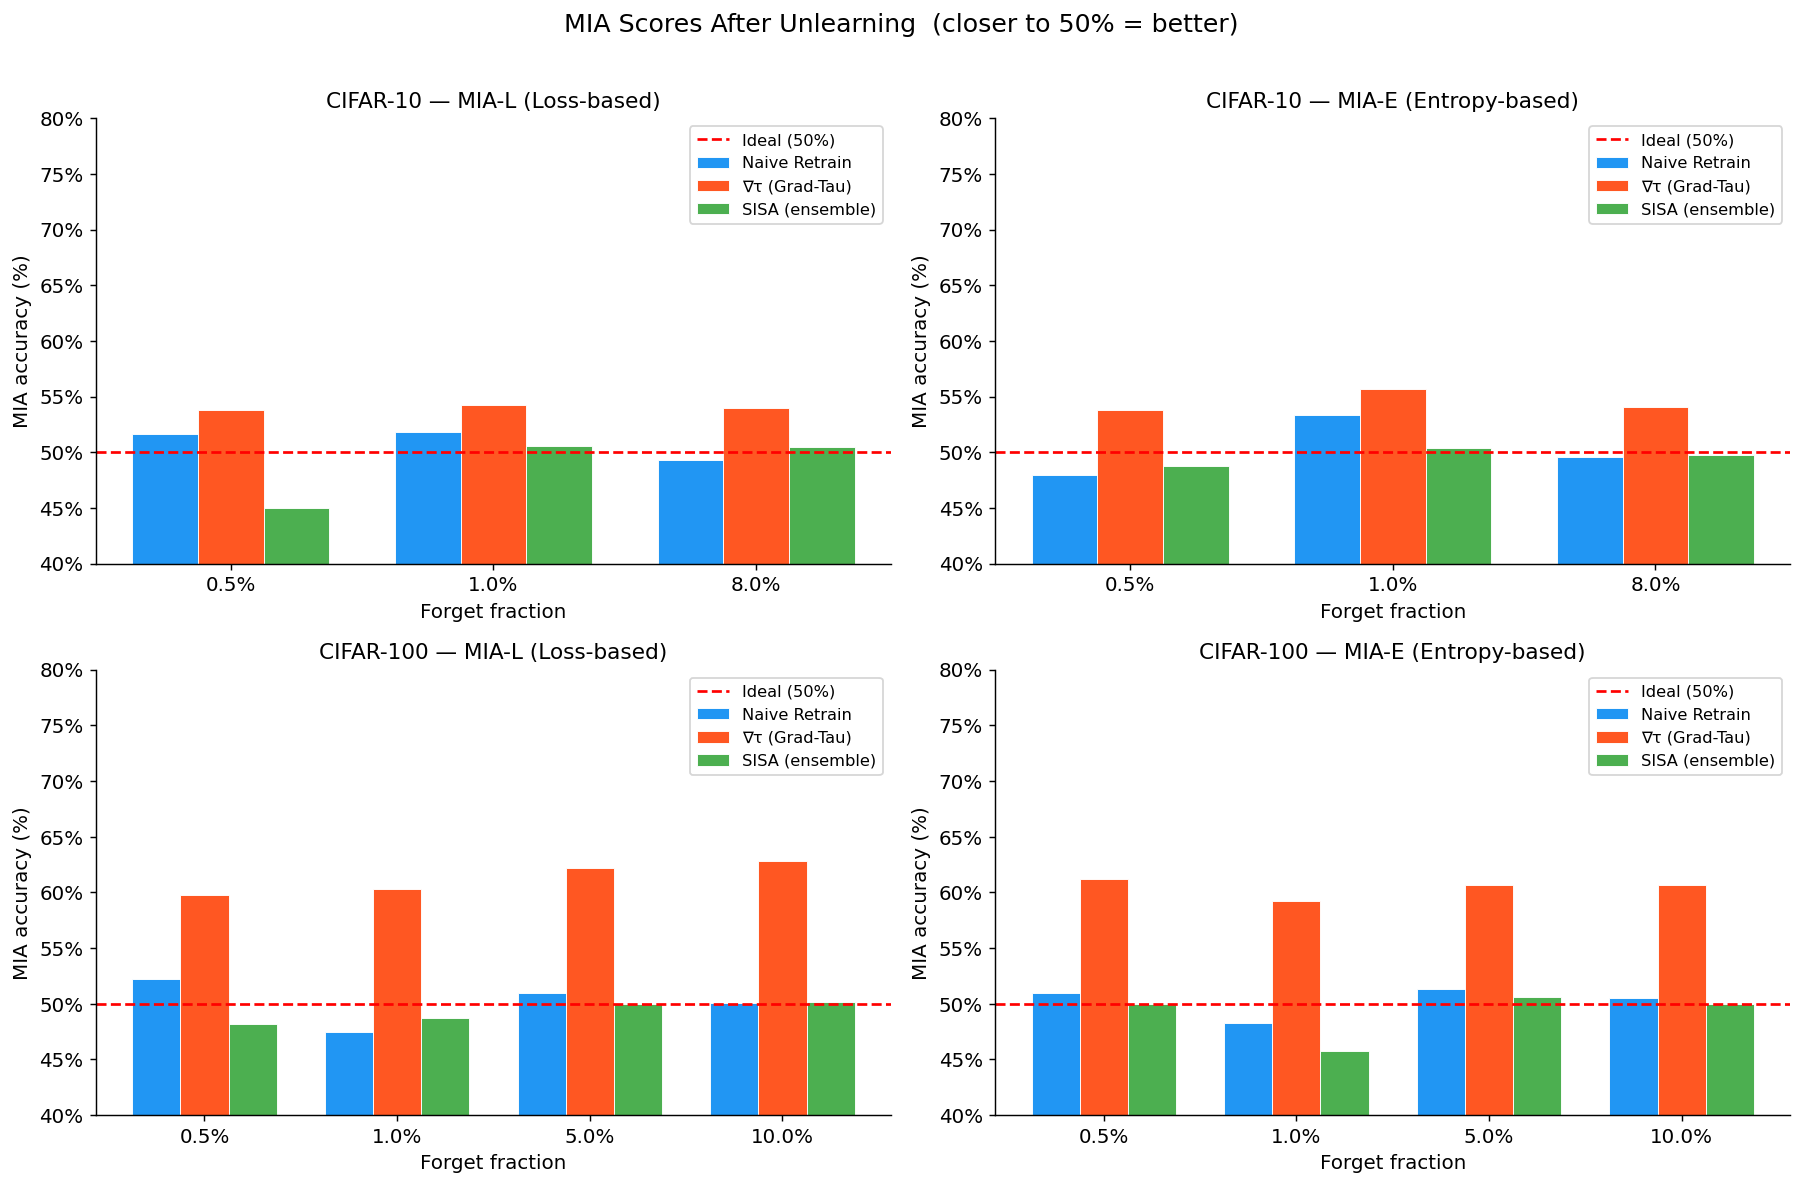

Saved → results_mia_scores.pdf / .png


In [6]:
def plot_mia(df, dataset_name, ax_l, ax_e):
    methods = ['naive_retrain', 'grad_tau', 'sisa']
    fracs = sorted(df['forget_fraction'].unique())
    x = np.arange(len(fracs))
    w = 0.25

    for i, method in enumerate(methods):
        sub = df[df['method'] == method].sort_values('forget_fraction')
        if sub.empty:
            continue
        offset = (i - 1) * w
        label  = METHOD_LABELS[method]
        color  = METHOD_COLORS[method]

        ax_l.bar(x + offset, sub['a_mia_l'].values, w, label=label,
                 color=color, edgecolor='white', linewidth=0.5)
        ax_e.bar(x + offset, sub['a_mia_e'].values, w, label=label,
                 color=color, edgecolor='white', linewidth=0.5)

    for ax, title in [(ax_l, 'MIA-L (Loss-based)'), (ax_e, 'MIA-E (Entropy-based)')]:
        ax.axhline(50, color='red', lw=1.5, ls='--', label='Ideal (50%)')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{f*100:.1f}%' for f in fracs])
        ax.set_xlabel('Forget fraction')
        ax.set_ylabel('MIA accuracy (%)')
        ax.set_ylim(40, 80)
        ax.set_title(f'{dataset_name} — {title}')
        ax.legend(loc='upper right')
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_mia(df10,  'CIFAR-10',  axes[0, 0], axes[0, 1])
plot_mia(df100, 'CIFAR-100', axes[1, 0], axes[1, 1])
fig.suptitle('MIA Scores After Unlearning  (closer to 50% = better)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('results_mia_scores.pdf', bbox_inches='tight')
plt.savefig('results_mia_scores.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → results_mia_scores.pdf / .png')

---
## 3 · Test Accuracy — Performance Preservation

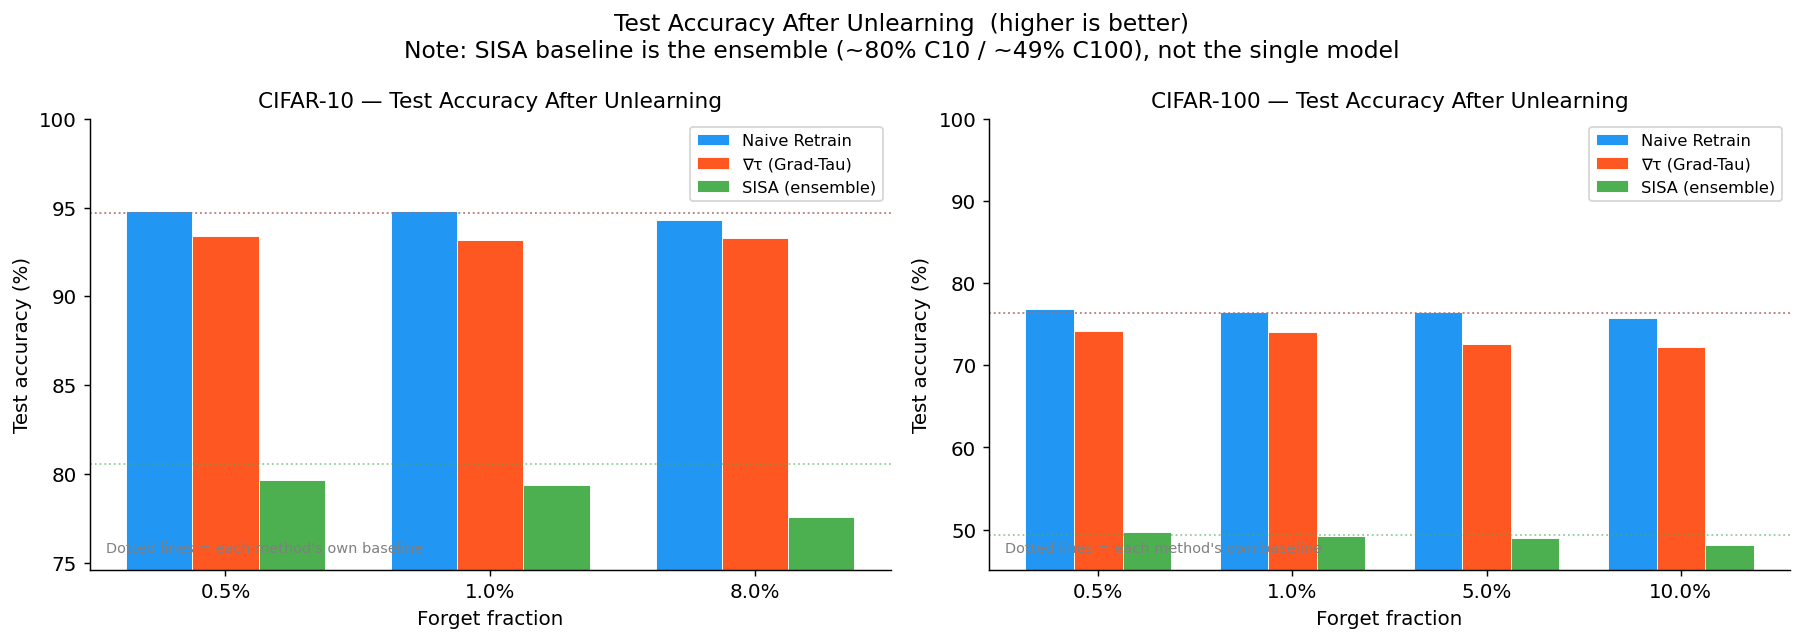

Saved → results_test_acc.pdf / .png


In [7]:
def plot_test_acc(df, dataset_name, ax):
    methods = ['naive_retrain', 'grad_tau', 'sisa']
    fracs = sorted(df['forget_fraction'].unique())
    x = np.arange(len(fracs))
    w = 0.25

    # Each method has its own 'before' baseline — plot separately
    for i, method in enumerate(methods):
        sub = df[df['method'] == method].sort_values('forget_fraction')
        if sub.empty:
            continue
        offset = (i - 1) * w
        color  = METHOD_COLORS[method]
        # Before baseline (dashed horizontal line per method at their own level)
        baseline = sub['b_test_acc'].mean()   # same across fracs within a method
        ax.axhline(baseline, color=color, lw=1, ls=':', alpha=0.6)

        bars = ax.bar(x + offset, sub['a_test_acc'].values, w,
                      label=METHOD_LABELS[method], color=color,
                      edgecolor='white', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{f*100:.1f}%' for f in fracs])
    ax.set_xlabel('Forget fraction')
    ax.set_ylabel('Test accuracy (%)')
    ax.set_title(f'{dataset_name} — Test Accuracy After Unlearning')
    ax.legend()
    # Note about SISA
    ax.annotate('Dotted lines = each method\'s own baseline',
                xy=(0.02, 0.04), xycoords='axes fraction', fontsize=8, color='gray')
    lo = min(df['a_test_acc'].min(), df['b_test_acc'].min()) - 3
    ax.set_ylim(max(0, lo), 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_test_acc(df10,  'CIFAR-10',  axes[0])
plot_test_acc(df100, 'CIFAR-100', axes[1])
fig.suptitle('Test Accuracy After Unlearning  (higher is better)\n'
             'Note: SISA baseline is the ensemble (~80% C10 / ~49% C100), not the single model',
             fontsize=13)
plt.tight_layout()
plt.savefig('results_test_acc.pdf', bbox_inches='tight')
plt.savefig('results_test_acc.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → results_test_acc.pdf / .png')

---
## 4 · Forget-Set Accuracy — How Much Did the Model Forget?

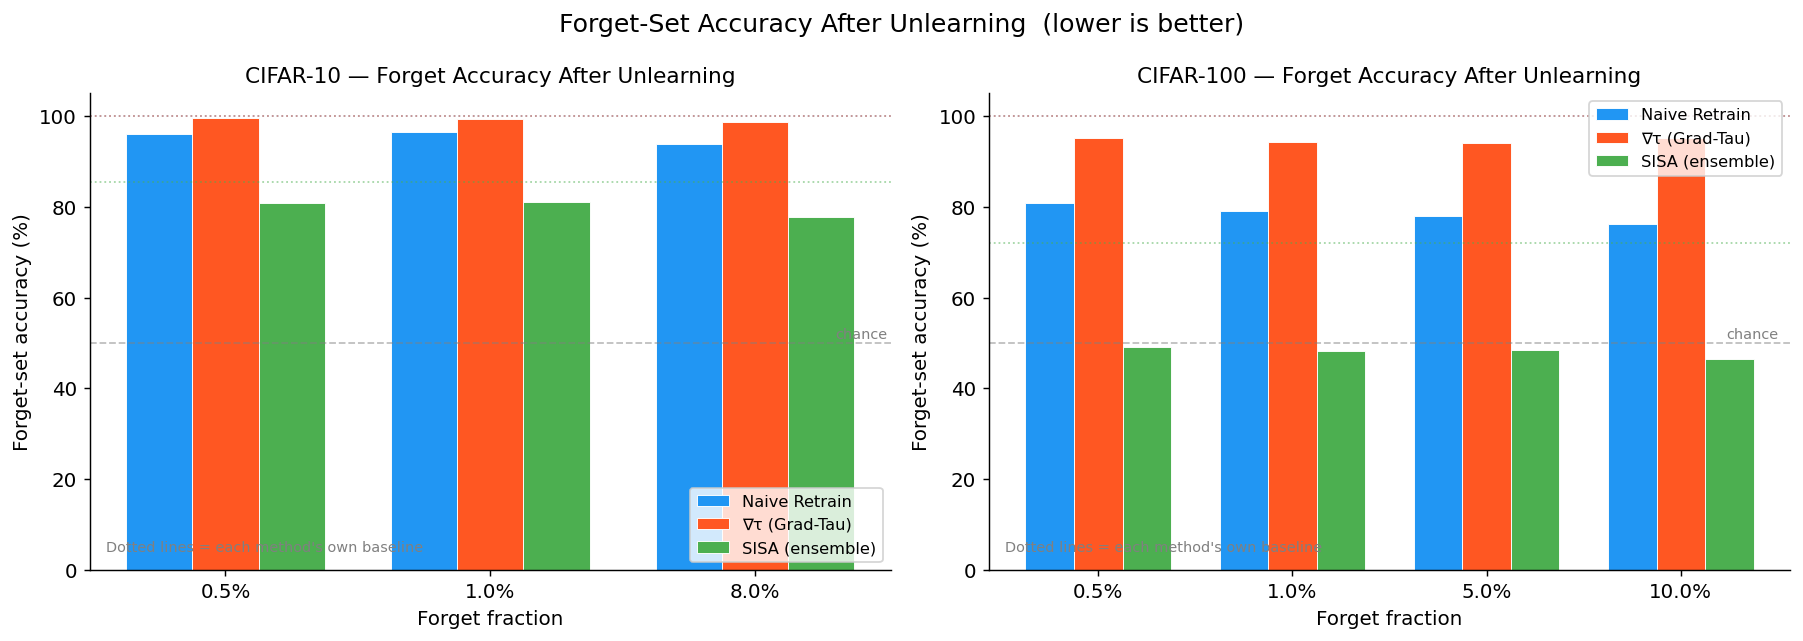

Saved → results_forget_acc.pdf / .png


In [8]:
def plot_forget_acc(df, dataset_name, ax):
    methods = ['naive_retrain', 'grad_tau', 'sisa']
    fracs = sorted(df['forget_fraction'].unique())
    x = np.arange(len(fracs))
    w = 0.25

    for i, method in enumerate(methods):
        sub = df[df['method'] == method].sort_values('forget_fraction')
        if sub.empty:
            continue
        offset = (i - 1) * w
        color  = METHOD_COLORS[method]
        # Before baseline per method
        ax.axhline(sub['b_forget_acc'].mean(), color=color, lw=1, ls=':', alpha=0.5)
        ax.bar(x + offset, sub['a_forget_acc'].values, w,
               label=METHOD_LABELS[method], color=color,
               edgecolor='white', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{f*100:.1f}%' for f in fracs])
    ax.set_xlabel('Forget fraction')
    ax.set_ylabel('Forget-set accuracy (%)')
    ax.set_title(f'{dataset_name} — Forget Accuracy After Unlearning')
    ax.legend()
    ax.set_ylim(0, 105)
    ax.axhline(50, color='gray', lw=1, ls='--', alpha=0.5)
    ax.text(len(fracs) - 0.5, 51, 'chance', ha='right', fontsize=8, color='gray')
    ax.annotate('Dotted lines = each method\'s own baseline',
                xy=(0.02, 0.04), xycoords='axes fraction', fontsize=8, color='gray')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_forget_acc(df10,  'CIFAR-10',  axes[0])
plot_forget_acc(df100, 'CIFAR-100', axes[1])
fig.suptitle('Forget-Set Accuracy After Unlearning  (lower is better)', fontsize=14)
plt.tight_layout()
plt.savefig('results_forget_acc.pdf', bbox_inches='tight')
plt.savefig('results_forget_acc.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → results_forget_acc.pdf / .png')

---
## 5 · Unlearning Time — Efficiency

**Important:** Two different reference points:
- **∇τ and Naive Retrain** share the same single-model setup → compare to each other
- **SISA** is its own ensemble paradigm → compare unlearning time to **SISA full re-train time**

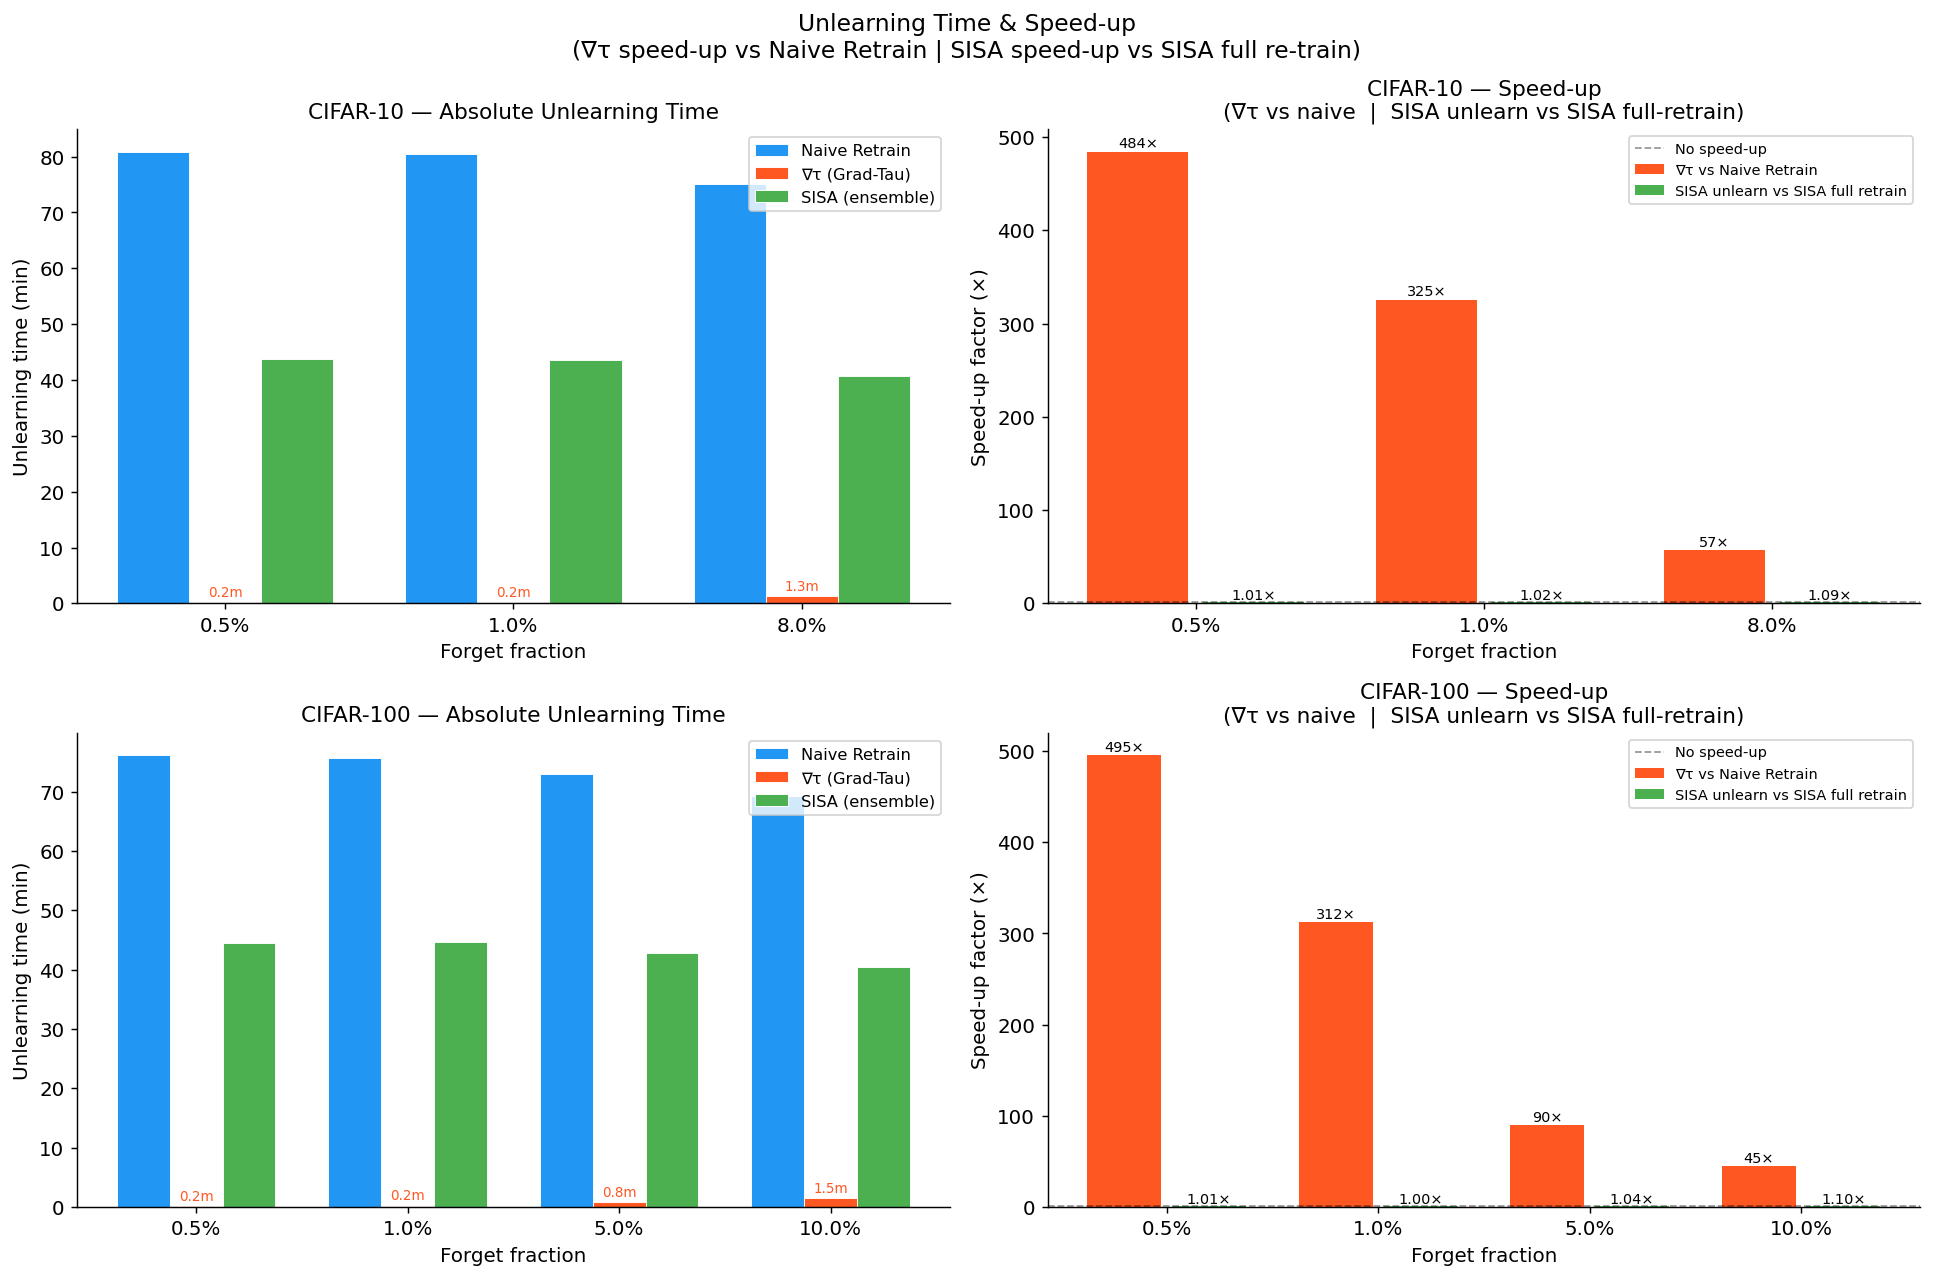

Saved → results_time.pdf / .png


In [9]:
def plot_time(df, dataset_name, ax_abs, ax_speedup):
    methods = ['naive_retrain', 'grad_tau', 'sisa']
    fracs   = sorted(df['forget_fraction'].unique())
    x = np.arange(len(fracs))
    w = 0.25

    # ── Absolute time ─────────────────────────────────────────────────────────
    for i, method in enumerate(methods):
        sub = df[df['method'] == method].sort_values('forget_fraction')
        if sub.empty: continue
        offset = (i - 1) * w
        times_min = sub['unlearn_time_s'].values / 60
        bars = ax_abs.bar(x + offset, times_min, w,
                          label=METHOD_LABELS[method], color=METHOD_COLORS[method],
                          edgecolor='white', linewidth=0.5)
        if method == 'grad_tau':   # annotate since bars are tiny
            for bar, t in zip(bars, times_min):
                ax_abs.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                            f'{t:.1f}m', ha='center', va='bottom', fontsize=7.5,
                            color=METHOD_COLORS['grad_tau'])

    ax_abs.set_xticks(x)
    ax_abs.set_xticklabels([f'{f*100:.1f}%' for f in fracs])
    ax_abs.set_xlabel('Forget fraction')
    ax_abs.set_ylabel('Unlearning time (min)')
    ax_abs.set_title(f'{dataset_name} — Absolute Unlearning Time')
    ax_abs.legend()

    # ── Speed-up ──────────────────────────────────────────────────────────────
    naive_sub = df[df['method'] == 'naive_retrain'].sort_values('forget_fraction')
    gt_sub    = df[df['method'] == 'grad_tau'].sort_values('forget_fraction')
    sisa_sub  = df[df['method'] == 'sisa'].sort_values('forget_fraction')

    if not gt_sub.empty and not naive_sub.empty:
        su_gt = naive_sub['unlearn_time_s'].values / gt_sub['unlearn_time_s'].values
        bars = ax_speedup.bar(x - 0.2, su_gt, 0.35,
                              label='∇τ vs Naive Retrain',
                              color=METHOD_COLORS['grad_tau'])
        for bar, v in zip(bars, su_gt):
            ax_speedup.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                            f'{v:.0f}×', ha='center', va='bottom', fontsize=8)

    if not sisa_sub.empty and sisa_sub['sisa_train_time_s'].notna().any():
        su_sisa = sisa_sub['sisa_train_time_s'].values / sisa_sub['unlearn_time_s'].values
        bars = ax_speedup.bar(x + 0.2, su_sisa, 0.35,
                              label='SISA unlearn vs SISA full retrain',
                              color=METHOD_COLORS['sisa'])
        for bar, v in zip(bars, su_sisa):
            ax_speedup.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                            f'{v:.2f}×', ha='center', va='bottom', fontsize=8)

    ax_speedup.axhline(1, color='black', lw=1, ls='--', alpha=0.4, label='No speed-up')
    ax_speedup.set_xticks(x)
    ax_speedup.set_xticklabels([f'{f*100:.1f}%' for f in fracs])
    ax_speedup.set_xlabel('Forget fraction')
    ax_speedup.set_ylabel('Speed-up factor (×)')
    ax_speedup.set_title(f'{dataset_name} — Speed-up\n(∇τ vs naive  |  SISA unlearn vs SISA full-retrain)')
    ax_speedup.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_time(df10,  'CIFAR-10',  axes[0, 0], axes[0, 1])
plot_time(df100, 'CIFAR-100', axes[1, 0], axes[1, 1])
fig.suptitle('Unlearning Time & Speed-up\n'
             '(∇τ speed-up vs Naive Retrain | SISA speed-up vs SISA full re-train)',
             fontsize=13)
plt.tight_layout()
plt.savefig('results_time.pdf', bbox_inches='tight')
plt.savefig('results_time.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved → results_time.pdf / .png')

---
## 6 · Comprehensive Comparison: Before vs After (All Metrics, per Method)

Each row = one unlearning method. Each column = one metric.  
Grey dashed line = that method's **own** baseline before unlearning.  
Coloured solid line = after unlearning.  
Red dashed line (MIA only) = ideal 50% target.

**SISA row uses the SISA ensemble baseline** — its y-axis range is independent from the other rows.

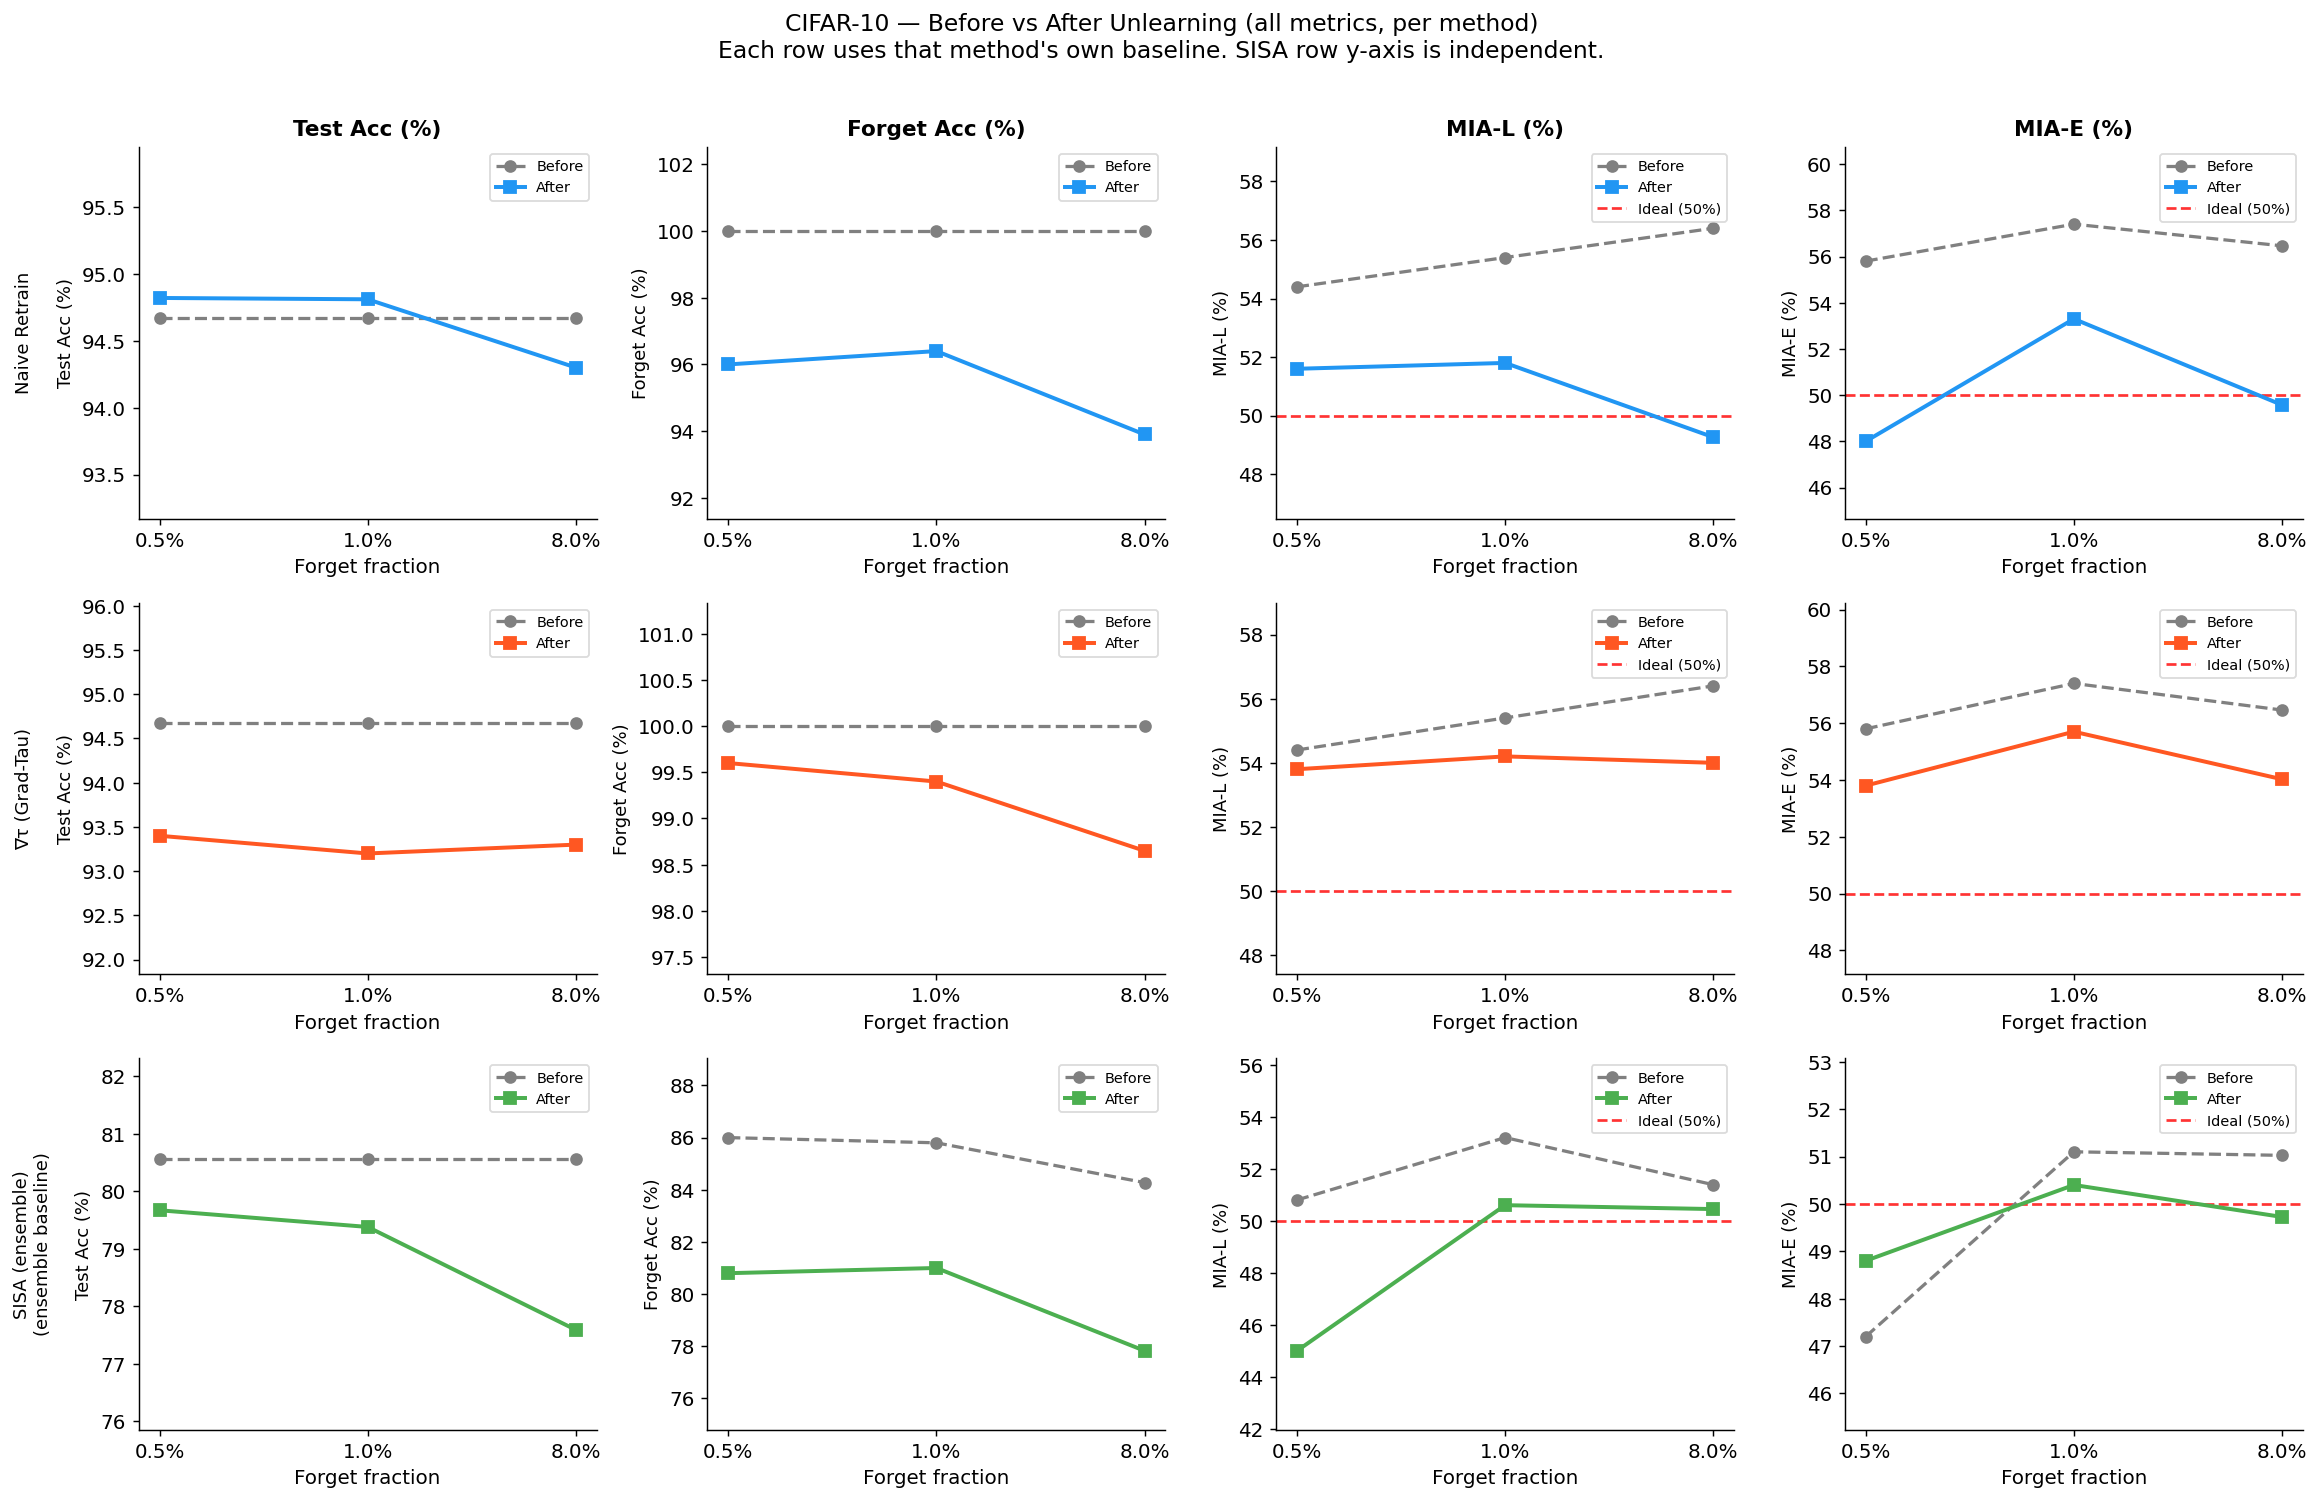

Saved → results_cifar10_before_after.pdf / .png


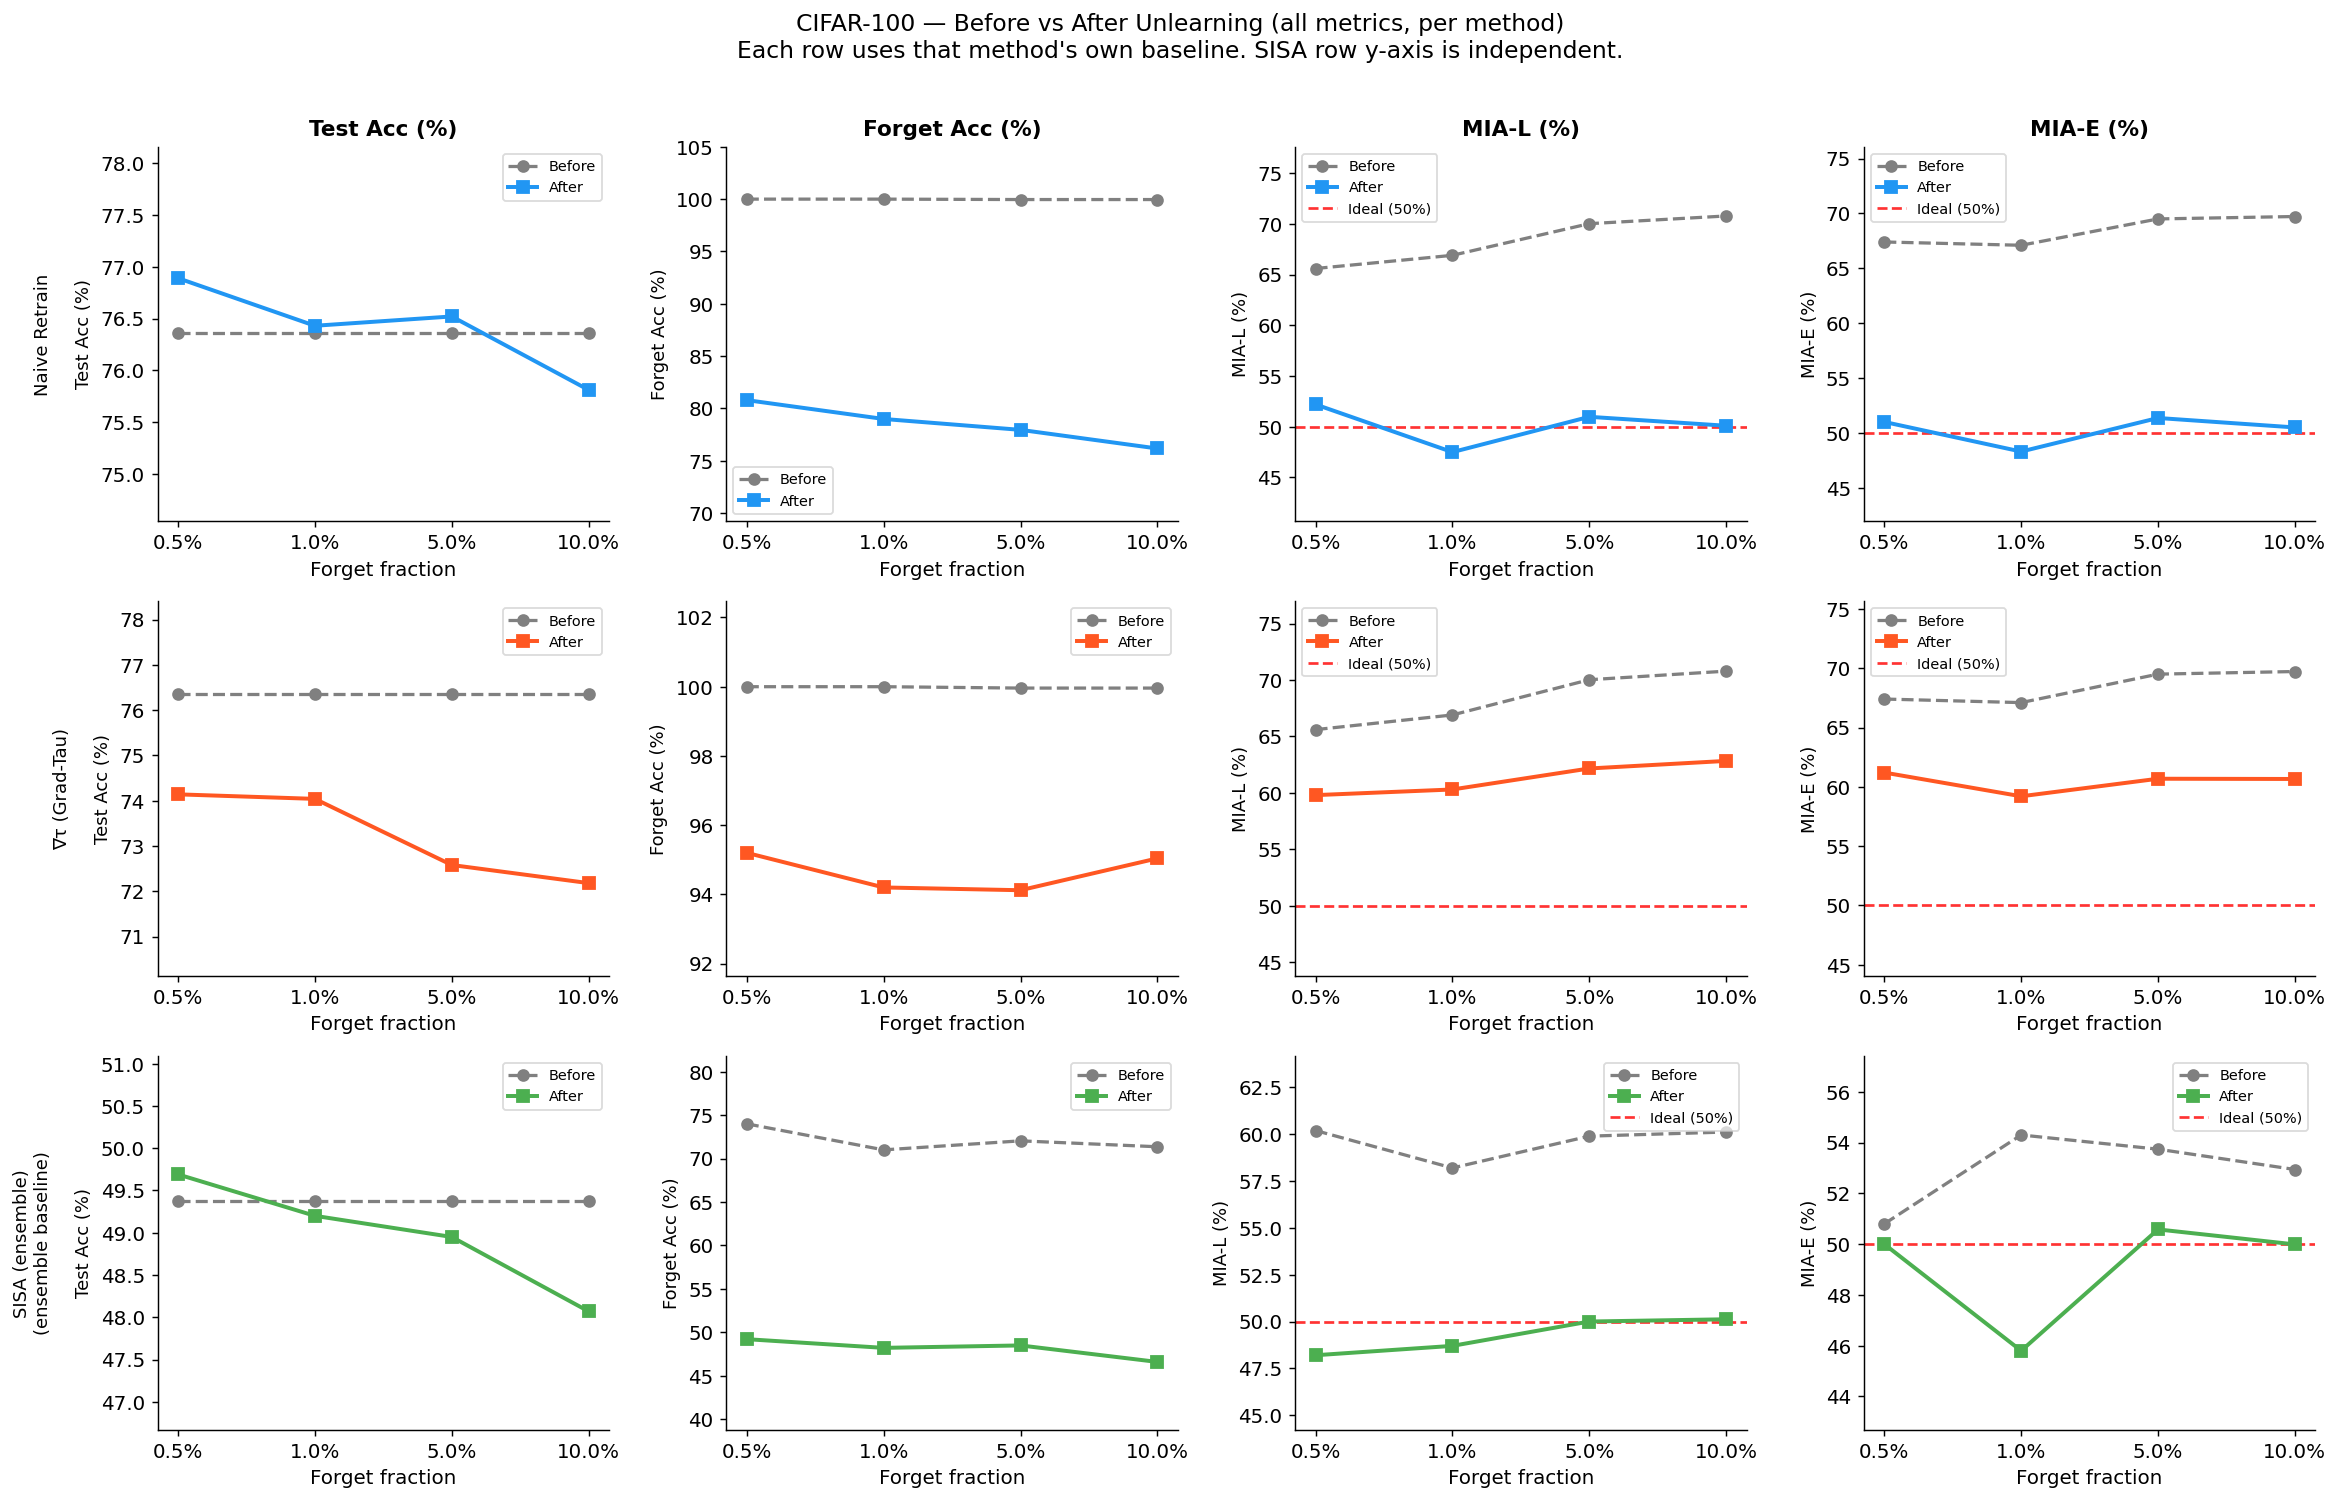

Saved → results_cifar100_before_after.pdf / .png


In [10]:
def plot_before_after(df, dataset_name):
    metrics = [
        ('test_acc',   'Test Acc (%)',     None),
        ('forget_acc', 'Forget Acc (%)',   None),
        ('mia_l',      'MIA-L (%)',        50),
        ('mia_e',      'MIA-E (%)',        50),
    ]
    methods = ['naive_retrain', 'grad_tau', 'sisa']
    fracs   = sorted(df['forget_fraction'].unique())
    n_rows  = len(methods)
    n_cols  = len(metrics)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.8 * n_rows))

    for row, method in enumerate(methods):
        sub = df[df['method'] == method].sort_values('forget_fraction')
        if sub.empty:
            for col in range(n_cols):
                axes[row, col].set_visible(False)
            continue

        # Reindex to all fracs (fills NaN if a fraction is missing for this method)
        sub_idx = sub.set_index('forget_fraction').reindex(fracs)
        x = np.arange(len(fracs))
        color = METHOD_COLORS[method]

        for col, (metric, col_title, hline) in enumerate(metrics):
            ax = axes[row, col]
            before_vals = sub_idx[f'b_{metric}'].values.astype(float)
            after_vals  = sub_idx[f'a_{metric}'].values.astype(float)

            # Determine ylim dynamically from this method's own data range
            all_vals = np.concatenate([before_vals[~np.isnan(before_vals)],
                                       after_vals[~np.isnan(after_vals)]])
            if hline is not None:
                all_vals = np.append(all_vals, hline)
            pad = (all_vals.max() - all_vals.min()) * 0.25 + 1
            ylo = max(0, all_vals.min() - pad)
            yhi = min(105, all_vals.max() + pad)

            # Plot before/after lines
            ax.plot(x, before_vals, 'o--', color='gray',  label='Before', lw=1.8, ms=6, zorder=3)
            ax.plot(x, after_vals,  's-',  color=color,   label='After',  lw=2.2, ms=7, zorder=4)

            if hline is not None:
                ax.axhline(hline, color='red', lw=1.5, ls='--', alpha=0.8, label='Ideal (50%)', zorder=2)

            ax.set_ylim(ylo, yhi)
            ax.set_xticks(x)
            ax.set_xticklabels([f'{f*100:.1f}%' for f in fracs])
            ax.set_xlabel('Forget fraction')

            # Column header (metric name) — top row only
            if row == 0:
                ax.set_title(col_title, fontsize=12, fontweight='bold')

            # Row label (method name) — left column only
            if col == 0:
                sisa_note = '\n(ensemble baseline)' if method == 'sisa' else ''
                ax.set_ylabel(f'{METHOD_LABELS[method]}{sisa_note}\n\n{col_title}',
                              fontsize=10)
            else:
                ax.set_ylabel(col_title, fontsize=10)

            # ── Legend on every subplot ────────────────────────────────────────
            ax.legend(loc='best', fontsize=8, framealpha=0.7)

    fig.suptitle(f'{dataset_name} — Before vs After Unlearning (all metrics, per method)\n'
                 f'Each row uses that method\'s own baseline. SISA row y-axis is independent.',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    safe = dataset_name.lower().replace('-', '')
    plt.savefig(f'results_{safe}_before_after.pdf', bbox_inches='tight')
    plt.savefig(f'results_{safe}_before_after.png', bbox_inches='tight', dpi=200)
    plt.show()
    print(f'Saved → results_{safe}_before_after.pdf / .png')

plot_before_after(df10,  'CIFAR-10')
plot_before_after(df100, 'CIFAR-100')

---
## 7 · Timing Summary Table

In [11]:
def timing_table(df, dataset_name):
    rows = []
    for frac in sorted(df['forget_fraction'].unique()):
        sub = df[df['forget_fraction'] == frac].set_index('method')
        times   = sub['unlearn_time_s']
        sisa_tr = sub['sisa_train_time_s'] if 'sisa_train_time_s' in sub.columns else {}

        naive_t = times.get('naive_retrain')
        gt_t    = times.get('grad_tau')
        sisa_t  = times.get('sisa')
        sisa_full = sisa_tr.get('sisa') if hasattr(sisa_tr, 'get') else None

        row = {
            'Dataset': dataset_name,
            'Forget %': f'{frac*100:.1f}%',
            'Naive (min)':  f'{naive_t/60:.1f}' if naive_t else '—',
            '∇τ (min)':     f'{gt_t/60:.2f}'    if gt_t    else '—',
            'SISA unlearn (min)': f'{sisa_t/60:.1f}' if sisa_t else '—',
            'SISA full retrain (min)': f'{sisa_full/60:.1f}' if sisa_full else '—',
            '∇τ speed-up vs Naive': f'{naive_t/gt_t:.0f}×'     if (naive_t and gt_t)    else '—',
            'SISA speed-up vs SISA retrain': f'{sisa_full/sisa_t:.2f}×' if (sisa_full and sisa_t) else '—',
        }
        rows.append(row)
    return pd.DataFrame(rows)

t10  = timing_table(df10,  'CIFAR-10')
t100 = timing_table(df100, 'CIFAR-100')
combined = pd.concat([t10, t100], ignore_index=True)
display(combined)
print('\nNote: SISA speed-up ≈ 1× here because all 5 shards were affected and retrained from slice 0.')
print('SISA\'s efficiency advantage shows when only a subset of shards/slices need retraining.')

,Dataset,Forget %,Naive (min),∇τ (min),SISA unlearn (min),SISA full retrain (min),∇τ speed-up vs Naive,SISA speed-up vs SISA retrain
0,CIFAR-10,0.5%,80.9,0.17,43.8,44.4,484×,1.01×
1,CIFAR-10,1.0%,80.5,0.25,43.6,44.4,325×,1.02×
2,CIFAR-10,8.0%,75.1,1.32,40.8,44.4,57×,1.09×
3,CIFAR-100,0.5%,76.1,0.15,44.5,44.7,495×,1.01×
4,CIFAR-100,1.0%,75.7,0.24,44.7,44.7,312×,1.00×
5,CIFAR-100,5.0%,73.0,0.81,42.8,44.7,90×,1.04×
6,CIFAR-100,10.0%,69.3,1.53,40.5,44.7,45×,1.10×



Note: SISA speed-up ≈ 1× here because all 5 shards were affected and retrained from slice 0.
SISA's efficiency advantage shows when only a subset of shards/slices need retraining.


---
## 8 · Key Findings Summary

In [12]:
print("="*75)
print("KEY FINDINGS  (seed 42, random forget strategy)")
print("="*75)

for df, ds in [(df10, 'CIFAR-10'), (df100, 'CIFAR-100')]:
    print(f"\n{'─'*55}")
    print(f"  {ds}")
    print(f"{'─'*55}")
    for method in ['naive_retrain', 'grad_tau', 'sisa']:
        sub = df[df['method'] == method].sort_values('forget_fraction')
        if sub.empty: continue
        baseline_note = ' [ensemble baseline]' if method == 'sisa' else ' [single-model baseline]'
        print(f"\n  {METHOD_LABELS[method]}{baseline_note}:")
        for _, r in sub.iterrows():
            mia_avg_after  = (r['a_mia_l'] + r['a_mia_e']) / 2
            mia_dist_ideal = abs(mia_avg_after - 50)
            acc_delta      = r['a_test_acc'] - r['b_test_acc']
            t_min          = r['unlearn_time_s'] / 60
            print(f"    Forget {r['forget_fraction']*100:.1f}%: "
                  f"MIA-L={r['a_mia_l']:.1f}% MIA-E={r['a_mia_e']:.1f}% "
                  f"(dist from 50%={mia_dist_ideal:.1f}pp)  "
                  f"ΔTestAcc={acc_delta:+.2f}pp  "
                  f"Time={t_min:.1f}min")

print("\n" + "="*75)
print("TAKE-AWAYS")
print("="*75)
print("""
1. Naive Retrain  → gold standard: MIA ≈ 50% on both datasets.
   Cost: ~70-80 min full retraining.

2. ∇τ (Grad-Tau) → 50-500× faster than naive retrain, but MIA still
   detectable on CIFAR-100 (60-63%), and forget-acc stays high (~95%).
   Unlearning is INCOMPLETE, especially on the harder 100-class task.

3. SISA           → MIA ≈ 50% (good unlearning quality).
   BUT: ensemble accuracy is structurally lower (~49% vs 76% on C100)
   due to sharding. Speed-up vs its own full retrain is marginal (~1×)
   when all shards are affected — SISA gains efficiency only when
   forget samples are concentrated in few shards/late slices.
""")

KEY FINDINGS  (seed 42, random forget strategy)

───────────────────────────────────────────────────────
  CIFAR-10
───────────────────────────────────────────────────────

  Naive Retrain [single-model baseline]:
    Forget 0.5%: MIA-L=51.6% MIA-E=48.0% (dist from 50%=0.2pp)  ΔTestAcc=+0.15pp  Time=80.9min
    Forget 1.0%: MIA-L=51.8% MIA-E=53.3% (dist from 50%=2.6pp)  ΔTestAcc=+0.14pp  Time=80.5min
    Forget 8.0%: MIA-L=49.3% MIA-E=49.6% (dist from 50%=0.6pp)  ΔTestAcc=-0.37pp  Time=75.1min

  ∇τ (Grad-Tau) [single-model baseline]:
    Forget 0.5%: MIA-L=53.8% MIA-E=53.8% (dist from 50%=3.8pp)  ΔTestAcc=-1.27pp  Time=0.2min
    Forget 1.0%: MIA-L=54.2% MIA-E=55.7% (dist from 50%=5.0pp)  ΔTestAcc=-1.47pp  Time=0.2min
    Forget 8.0%: MIA-L=54.0% MIA-E=54.0% (dist from 50%=4.0pp)  ΔTestAcc=-1.37pp  Time=1.3min

  SISA (ensemble) [ensemble baseline]:
    Forget 0.5%: MIA-L=45.0% MIA-E=48.8% (dist from 50%=3.1pp)  ΔTestAcc=-0.90pp  Time=43.8min
    Forget 1.0%: MIA-L=50.6% MIA-E=50.4% (

In [13]:
# List all saved figures
figs = sorted(glob.glob('results_*.png'))
print(f"{len(figs)} figures saved:")
for f in figs:
    print(f"  {f}")

8 figures saved:
  results_cifar100_before_after.png
  results_cifar10_before_after.png
  results_forget_acc.png
  results_mia_scores.png
  results_quality_score.png
  results_speedup.png
  results_test_acc.png
  results_time.png
